In [2]:
# Import the libraries we need
import pandas as pd
import numpy as np

# Load the dataset from the data folder
df = pd.read_csv("../data/creditcard.csv")

# Showing the size of the dataset
print("Dataset shape:", df.shape)

# Showing the first 5 rows to see what the data looks like
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Check the data types and look for any missing values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")

# Look at basic information about the columns
df.info()

Missing values per column:
0 total missing values
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     2

In [4]:
# Count how many transactions are legitimate (0) vs fraudulent (1)
class_counts = df["Class"].value_counts()
print("Class distribution (count):")
print(class_counts)

# Show the same thing as percentages
class_percent = df["Class"].value_counts(normalize=True) * 100
print("\nClass distribution (percentage):")
print(class_percent)

Class distribution (count):
Class
0    284315
1       492
Name: count, dtype: int64

Class distribution (percentage):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


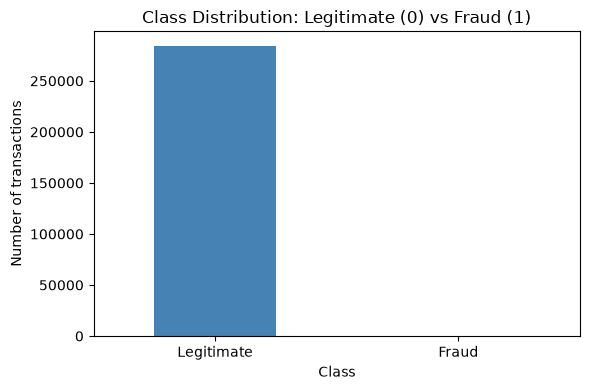

In [5]:
import matplotlib.pyplot as plt

# Create a bar chart of the class counts
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar", color=["steelblue", "crimson"])
plt.title("Class Distribution: Legitimate (0) vs Fraud (1)")
plt.xlabel("Class")
plt.ylabel("Number of transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"], rotation=0)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler

# Make a copy so we keep the original df intact
df_scaled = df.copy()

# Scale 'Time' and 'Amount' so they're on a similar scale to V1-V28
scaler = StandardScaler()
df_scaled[["Time", "Amount"]] = scaler.fit_transform(df_scaled[["Time", "Amount"]])

# Confirm the change by looking at the first few rows
df_scaled[["Time", "Amount"]].head()


,Time,Amount
0,-1.996583,0.244964
1,-1.996583,-0.342475
2,-1.996562,1.160686
3,-1.996562,0.140534
4,-1.996541,-0.073403


In [7]:
from sklearn.model_selection import train_test_split

# Separate the features (X) from the target label (Y)
X = df_scaled.drop("Class", axis=1)   # everything except the Class column
y = df_scaled["Class"]    # just the Class column

# Split into training and test sets (80% train, 20% test)
# stratify=y keeps the same fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_train.shape)
print("\nFraud cases in training set:", y_train.sum())
print("Fraud cases in test set", y_test.sum())

Training set shape: (227845, 30)
Test set shape: (227845, 30)

Fraud cases in training set: 394
Fraud cases in test set 98


In [8]:
# Diagnostic check - what are the actual sizes?
print("X_train rows:", X_train.shape[0])
print("X_test rows:", X_test.shape[0])
print("y_train rows:", y_train.shape[0])
print("y_test rows:", y_test.shape[0])
print("Total rows:", X_train.shape[0] + X_test.shape[0])

X_train rows: 227845
X_test rows: 56962
y_train rows: 227845
y_test rows: 56962
Total rows: 284807


In [9]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE ONLY to the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Compare before and after
print("Before SMOTE - training set class counts:")
print(y_train.value_counts())
print("\nAfter SMOTE - training set class counts:")
print(y_train_balanced.value_counts())

Before SMOTE - training set class counts:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE - training set class counts:
Class
0    227451
1    227451
Name: count, dtype: int64


In [10]:
import os

# Create a folder to hold the processed data (if it doesn't already exist)
os.makedirs("../data/processed", exist_ok=True)

# Save the balanced training set and the untouched test set
X_train_balanced.to_csv("../data/processed/X_train_balanced.csv", index=False)
y_train_balanced.to_csv("../data/processed/y_train_balanced.csv", index=False)
X_test.to_csv("../data/processed/X_test.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

print("Processed data saved successfully to data/processed/")

Processed data saved successfully to data/processed/
